# Разведочный анализ данных (EDA) мотоциклов

В этом ноутбуке мы проведем первичный анализ данных, найдем аномалии и выбросы, очистим датасет, а затем визуализируем распределения и зависимости на чистых данных.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Загрузка и анализ сырых данных
Загрузим исходный датасет и посмотрим на его базовые статистики и пропуски.

In [5]:
df = pd.read_csv("../data/raw/europe-motorbikes-zenrows.csv")
print(f"Размер сырого датасета: {df.shape}\n")

display(df.head())
display(df.describe())

print("\nПропуски в данных:")
print(df.isnull().sum())

Размер сырого датасета: (34917, 10)



,price,mileage,power,make_model,date,fuel,gear,offer_type,version,link
0,23990,150,218.0,Honda,03/2020,Gasoline,Manual,Demonstration,CBR1000RR-R Fireblade SP,/offers/honda-others-cbr1000rr-r-fireblade-sp-...
1,7500,2871,90.0,BMW F 800 GT,09/2018,Gasoline,Manual,Used,NaN,/offers/bmw-f-800-gt-gasoline-white-f65273c6-6...
2,800,1700,3.0,Nova Motors Retro Star,10/2019,Gasoline,NaN,Used,NaN,/offers/nova-motors-retro-star-gasoline-red-f8...
3,14990,24345,NaN,Aprilia RSV4,03/2016,Gasoline,NaN,Used,RF,/offers/aprilia-rsv4-rf-gasoline-silver-1b51fe...
4,6200,25000,128.0,Kawasaki Ninja ZX-6R,08/2009,Gasoline,NaN,Used,NaN,/offers/kawasaki-ninja-zx-6r-gasoline-blue-2f8...


,price,mileage,power
count,3.491700e+04,3.491700e+04,28598.000000
mean,4.568532e+04,2.183175e+04,206.157598
std,4.850120e+06,2.059421e+05,9371.426466
min,1.000000e+00,0.000000e+00,1.000000
25%,6.999000e+03,2.932000e+03,50.000000
50%,9.920000e+03,1.100000e+04,90.000000
75%,1.259000e+04,2.500000e+04,125.000000
max,8.888889e+08,9.999999e+06,913595.000000



Пропуски в данных:
price             0
mileage           0
power          6319
make_model        0
date              0
fuel           3190
gear          22070
offer_type        0
version       17504
link              0
dtype: int64


### Выводы по сырым данным
Как видно из таблицы `describe()` и подсчета пропусков, в данных присутствуют серьезные аномалии (выбросы):
1. **Цена (`price`)**: минимальная цена 1 у.е. (скорее всего заглушка), а максимальная — почти 889 млн. Из-за этого среднее значение сильно искажено.
2. **Пробег (`mileage`)**: максимальный пробег составляет почти 10 млн км, что физически невозможно для мотоцикла.
3. **Мощность (`power`)**: присутствует более 6000 пропущенных значений (NaN), а максимальная мощность достигает 913 595 л.с.

Строить графики на таких данных бессмысленно, так как из-за гигантских выбросов распределения будут нечитаемыми. Сначала очистим датасет.

## 2. Очистка данных
Отфильтруем выбросы по логичным порогам и заполним пропуски в мощности медианным значением (чтобы не терять почти 18% датасета, а также потому что медиана устойчива к выбросам).

In [6]:
# Удаляем дубликаты и пустые цены
df_clean = df.drop_duplicates().copy()
df_clean = df_clean.dropna(subset=['price'])

# Заполняем пропуски в мощности медианой
power_median = df_clean['power'].median()
df_clean['power'] = df_clean['power'].fillna(power_median)

# Фильтруем выбросы по логичным порогам
df_clean = df_clean[(df_clean['price'] > 100) & (df_clean['price'] < 100000)]
df_clean = df_clean[(df_clean['mileage'] >= 0) & (df_clean['mileage'] < 300000)]
df_clean = df_clean[(df_clean['power'] > 0) & (df_clean['power'] < 500)]

print(f"Размер датасета после очистки: {df_clean.shape}\n")
display(df_clean.describe())

Размер датасета после очистки: (28839, 10)



,price,mileage,power
count,28839.000000,28839.000000,28839.000000
mean,10295.997642,16971.634869,86.132841
std,7240.777707,19597.160204,50.841311
min,111.000000,0.000000,1.000000
25%,6500.000000,2600.000000,54.000000
50%,9000.000000,10571.000000,86.000000
75%,13350.000000,24350.000000,113.000000
max,99999.000000,265000.000000,485.000000


## 3. Визуализация очищенных данных (EDA)
Теперь, когда выбросы удалены, мы можем посмотреть на реальные распределения и зависимости.

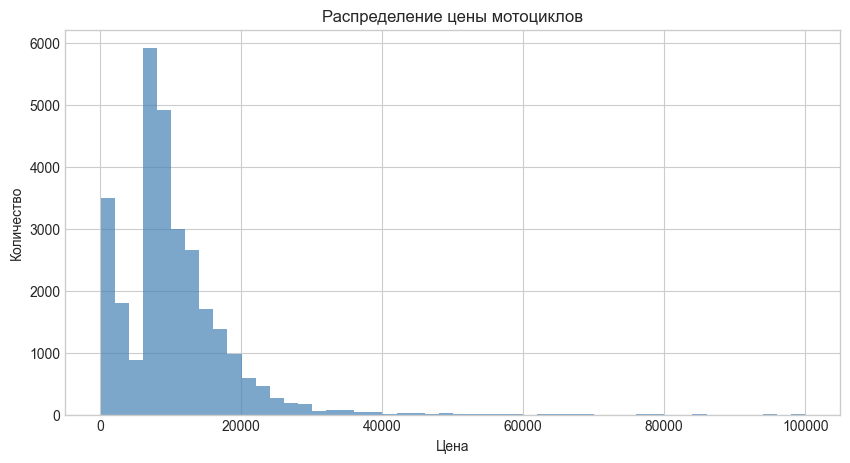

In [8]:
# Распределение цены
plt.figure(figsize=(10, 5))
plt.hist(df_clean['price'], bins=50, alpha=0.7, color='steelblue')
plt.title('Распределение цены мотоциклов')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.savefig('../report/images/price_dist.png')
plt.show()

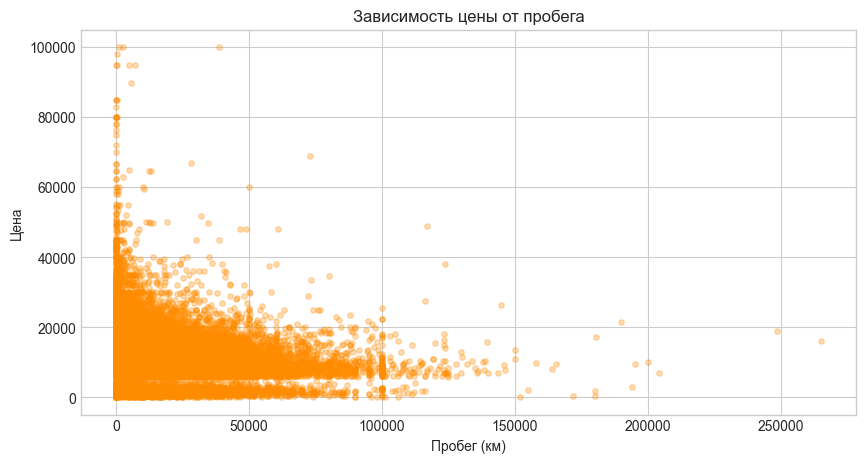

In [9]:
# Цена vs пробег
plt.figure(figsize=(10, 5))
plt.scatter(df_clean['mileage'], df_clean['price'], alpha=0.3, s=15, color='darkorange')
plt.title('Зависимость цены от пробега')
plt.xlabel('Пробег (км)')
plt.ylabel('Цена')
plt.savefig('../report/images/price_vs_mileage.png')
plt.show()

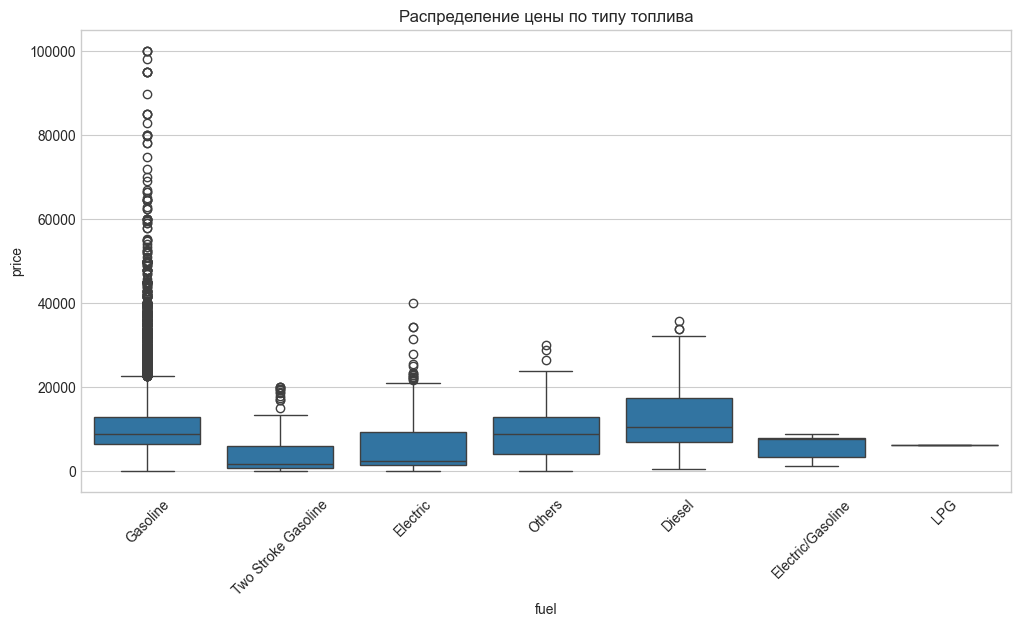

In [10]:
# Boxplot по типу топлива
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='fuel', y='price')
plt.title('Распределение цены по типу топлива')
plt.xticks(rotation=45)
plt.savefig('../report/images/price_by_fuel.png')
plt.show()

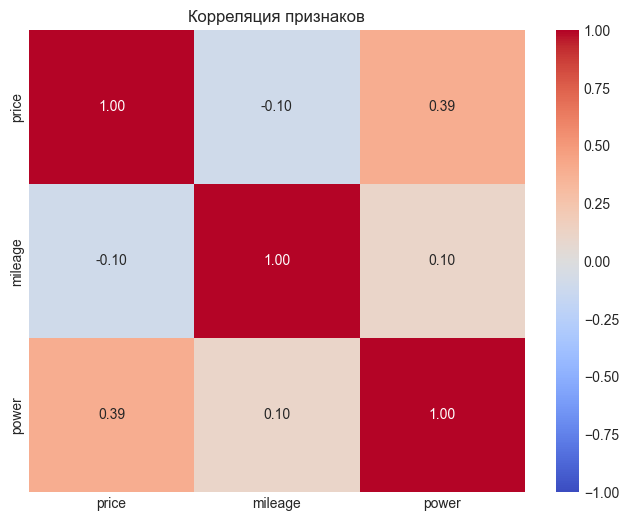

In [11]:
# Корреляция числовых признаков
numeric_cols = ['price', 'mileage', 'power']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Корреляция признаков')
plt.savefig('../report/images/correlation.png')
plt.show()

## 4. Feature Engineering (Создание новых признаков)
Для улучшения качества будущих моделей мы можем создать несколько новых признаков из существующих данных. Так как данные были собраны в 2021 году, мы будем использовать этот год для расчета возраста мотоциклов.

1. **Возраст (`age`)**: вычисляется как `2021 - год_выпуска`.
2. **Пробег в год (`mileage_per_year`)**: вычисляется как `mileage / age`.
3. **Марка (`brand`)**: извлекается первое слово из колонки `make_model`.

In [12]:
# 1. Возраст мотоцикла (age)
df_clean['year'] = pd.to_numeric(df_clean['date'].astype(str).str[-4:], errors='coerce')
df_clean['year'] = df_clean['year'].fillna(df_clean['year'].median())
df_clean['age'] = 2021 - df_clean['year']
df_clean['age'] = df_clean['age'].apply(lambda x: x if x > 0 else 1) # защита от деления на 0

# 2. Пробег в год (mileage_per_year)
df_clean['mileage_per_year'] = df_clean['mileage'] / df_clean['age']

# 3. Марка (brand)
df_clean['brand'] = df_clean['make_model'].astype(str).apply(lambda x: x.split()[0] if len(x.split()) > 0 else 'Unknown')

display(df_clean[['price', 'age', 'mileage_per_year', 'brand']].head())

,price,age,mileage_per_year,brand
0,23990,1.0,150.000000,Honda
1,7500,3.0,957.000000,BMW
2,800,2.0,850.000000,Nova
3,14990,5.0,4869.000000,Aprilia
4,6200,12.0,2083.333333,Kawasaki


### Анализ новых признаков
Посмотрим, как новые признаки (возраст и пробег в год) коррелируют с ценой мотоцикла.

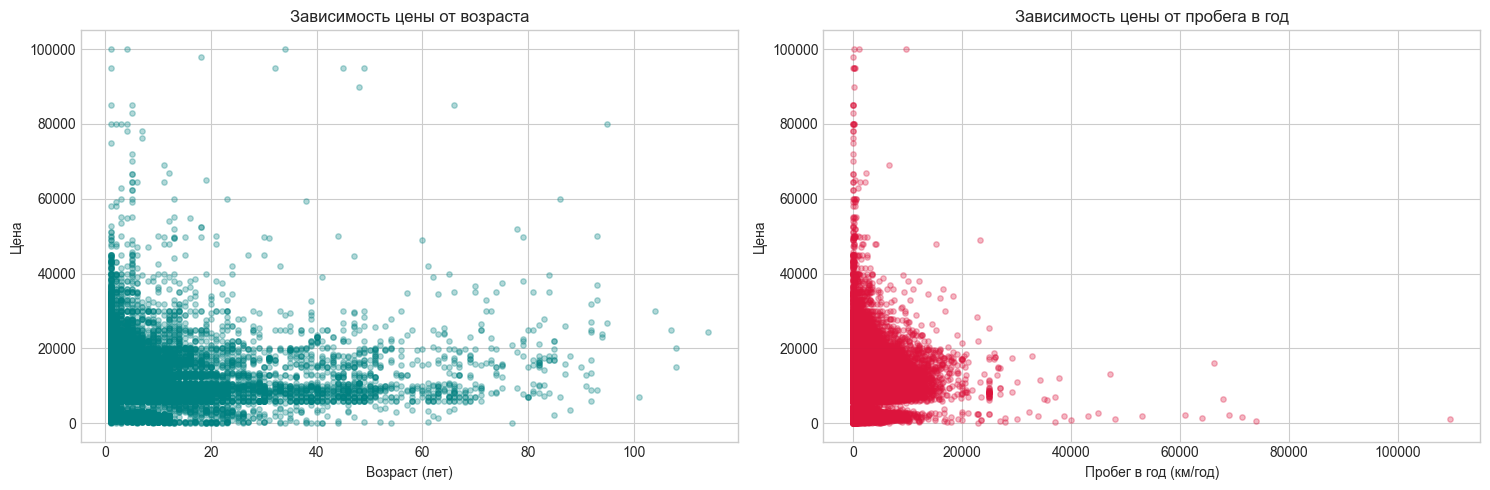

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Цена vs Возраст
axes[0].scatter(df_clean['age'], df_clean['price'], alpha=0.3, s=15, color='teal')
axes[0].set_title('Зависимость цены от возраста')
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Цена')

# Цена vs Пробег в год
axes[1].scatter(df_clean['mileage_per_year'], df_clean['price'], alpha=0.3, s=15, color='crimson')
axes[1].set_title('Зависимость цены от пробега в год')
axes[1].set_xlabel('Пробег в год (км/год)')
axes[1].set_ylabel('Цена')

plt.tight_layout()
plt.savefig('../report/images/new_features_vs_price.png')
plt.show()

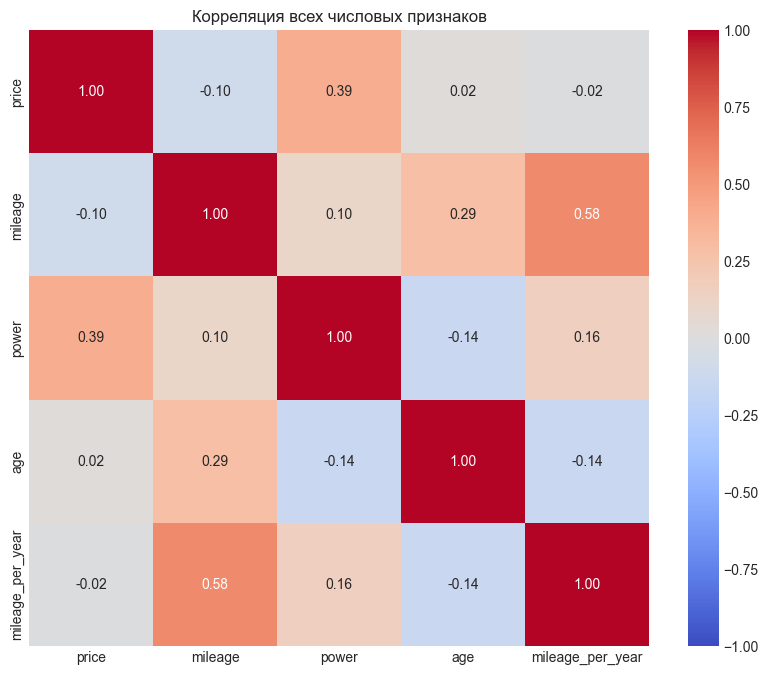

In [14]:
# Обновленная матрица корреляций со всеми числовыми признаками
numeric_cols_all = ['price', 'mileage', 'power', 'age', 'mileage_per_year']
corr_all = df_clean[numeric_cols_all].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Корреляция всех числовых признаков')
plt.savefig('../report/images/correlation_all.png')
plt.show()